In [1]:
# Cell 1: Import và load kết quả từ Notebook 6
import pickle, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 120
os.makedirs("figures", exist_ok=True)

with open("results/all_results.pkl", "rb") as f:
    all_results = pickle.load(f)

def build_dataframe(results):
    rows = []
    for (dataset, model), r in results.items():
        rows.append({'Dataset': dataset, 'Model': model,
                     'Params': r['params'], 'Train_s': r['train_time'],
                     'Acc': r['acc'], 'F1': r['f1']})
    return pd.DataFrame(rows)

df = build_dataframe(all_results)
print(df.to_string(index=False))

 Dataset       Model  Params     Train_s      Acc       F1
   MNIST    M1_Basic   19466  278.848435 0.938700 0.938093
   MNIST  M2_BN_Drop   28650  320.729849 0.970100 0.969785
   MNIST M3_Residual   77290  935.072622 0.993300 0.993278
   MNIST       M4_SE   20330  378.799835 0.941700 0.940901
CIFAR-10    M1_Basic   20042  734.901966 0.498300 0.487752
CIFAR-10  M2_BN_Drop   29226  831.415731 0.529600 0.528290
CIFAR-10 M3_Residual   77866 2139.581746 0.762100 0.761678
CIFAR-10       M4_SE   20906  937.696653 0.530200 0.523481
Diabetes    M1_Basic    1698    1.041397 0.758621 0.745853
Diabetes  M2_BN_Drop    3986    1.911259 0.732759 0.721823
Diabetes M3_Residual    7058    3.263197 0.741379 0.713816
Diabetes       M4_SE    2130    1.049485 0.724138 0.713845


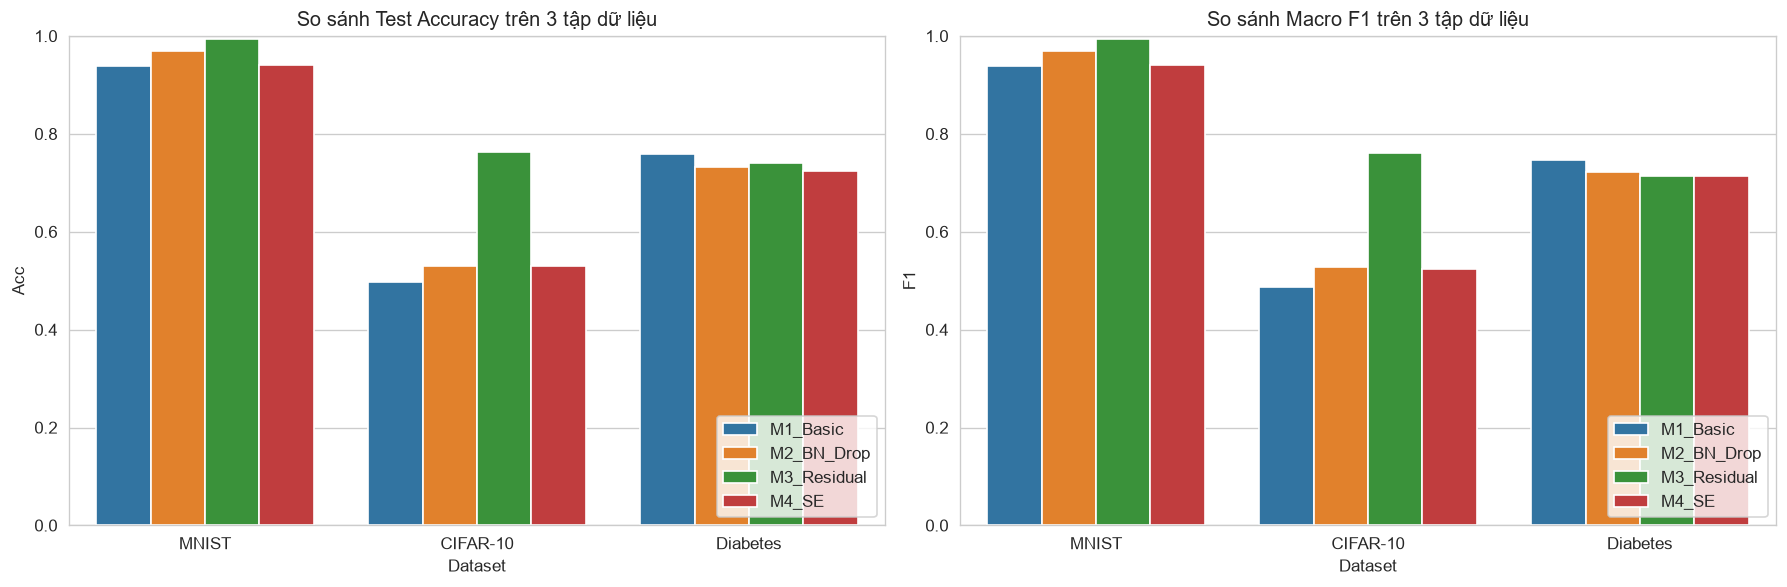

In [2]:
# Cell 2: Bar chart so sánh Accuracy / F1
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, metric, title in zip(axes, ['Acc', 'F1'],
                             ['Test Accuracy', 'Macro F1']):
    sns.barplot(data=df, x='Dataset', y=metric, hue='Model', ax=ax)
    ax.set_title(f"So sánh {title} trên 3 tập dữ liệu")
    ax.set_ylim(0, 1); ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig("figures/bar_acc_f1.png", dpi=200)
plt.show()

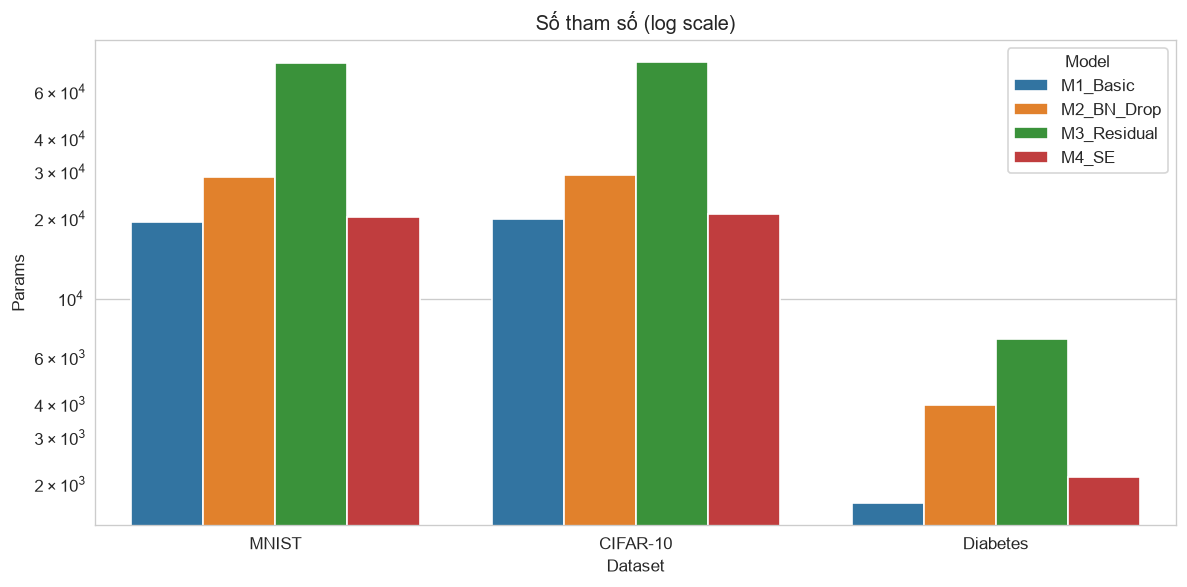

In [3]:
# Cell 3: Bar chart số tham số
plt.figure(figsize=(10, 5))
sns.barplot(data=df, x='Dataset', y='Params', hue='Model')
plt.yscale('log')
plt.title("Số tham số (log scale)")
plt.tight_layout()
plt.savefig("figures/bar_params.png", dpi=200)
plt.show()

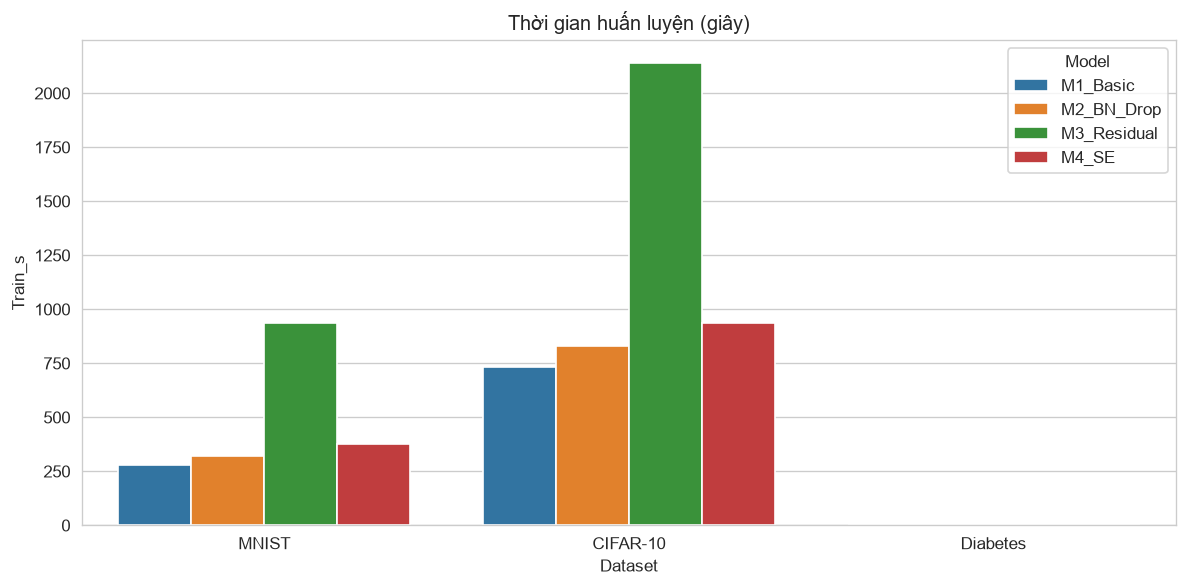

In [4]:
# Cell 4: Bar chart thời gian train
plt.figure(figsize=(10, 5))
sns.barplot(data=df, x='Dataset', y='Train_s', hue='Model')
plt.title("Thời gian huấn luyện (giây)")
plt.tight_layout()
plt.savefig("figures/bar_train_time.png", dpi=200)
plt.show()

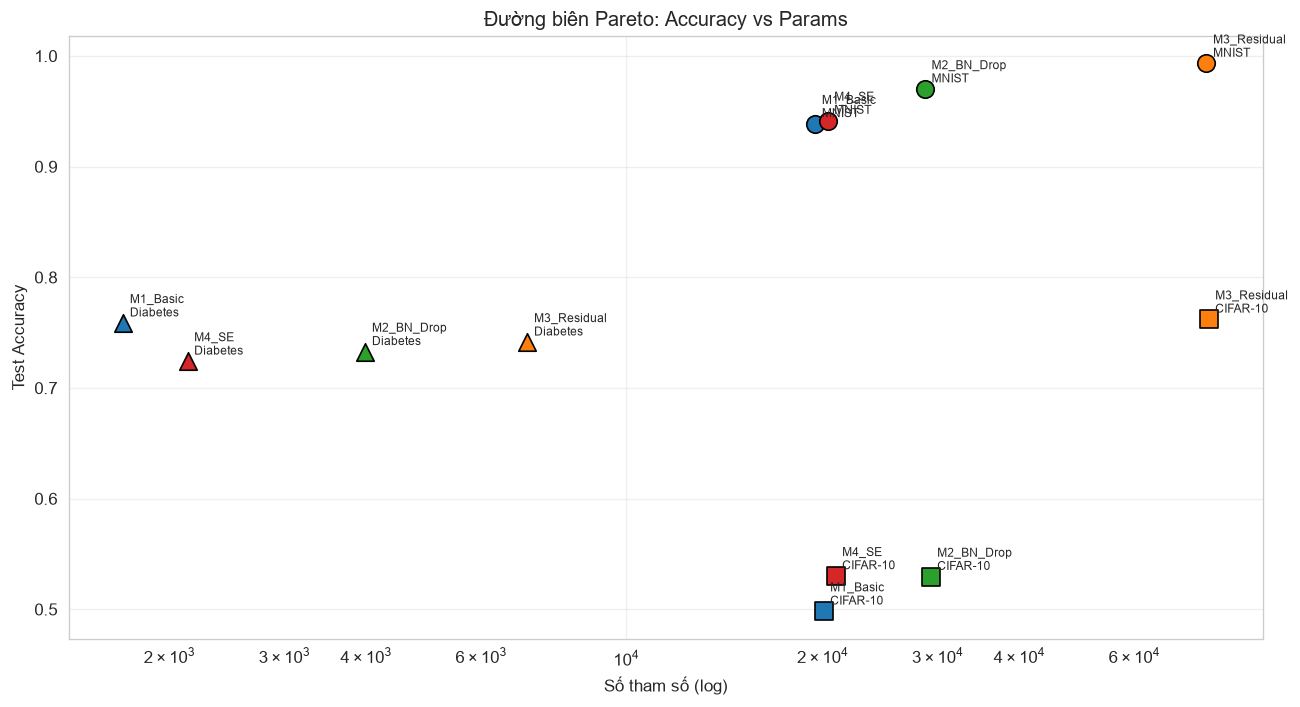

In [5]:
# Cell 5: Đường biên Pareto — Accuracy vs Params
plt.figure(figsize=(11, 6))
markers = {'MNIST':'o', 'CIFAR-10':'s', 'Diabetes':'^'}
colors  = {'M1_Basic':'#1f77b4', 'M2_BN_Drop':'#2ca02c',
           'M3_Residual':'#ff7f0e', 'M4_SE':'#d62728'}
for _, row in df.iterrows():
    plt.scatter(row['Params'], row['Acc'],
                marker=markers[row['Dataset']],
                color=colors[row['Model']],
                s=110, edgecolor='k')
    plt.annotate(f"{row['Model']}\n{row['Dataset']}",
                 (row['Params'], row['Acc']),
                 fontsize=7, xytext=(4, 4), textcoords='offset points')
plt.xscale('log')
plt.xlabel("Số tham số (log)"); plt.ylabel("Test Accuracy")
plt.title("Đường biên Pareto: Accuracy vs Params")
plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig("figures/pareto.png", dpi=200)
plt.show()

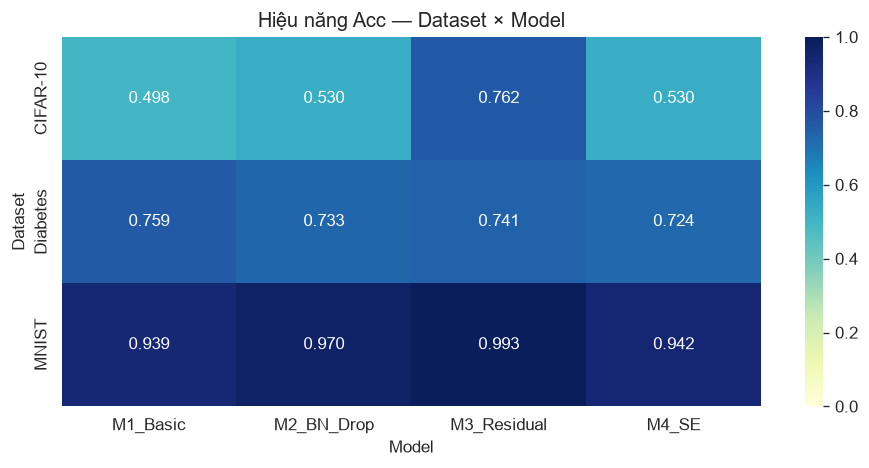

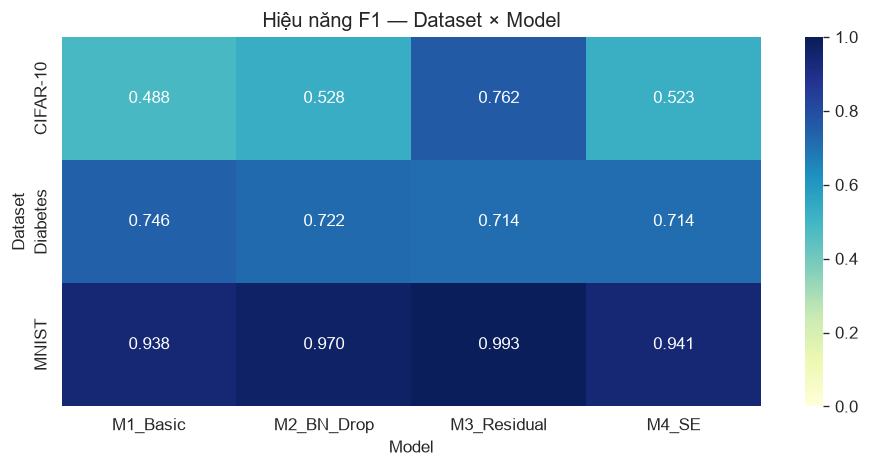

In [10]:
# Cell 6: Heatmap Dataset × Model
for metric in ['Acc', 'F1']:
    pivot = df.pivot(index='Dataset', columns='Model', values=metric)
    plt.figure(figsize=(8, 4))
    sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlGnBu', vmin=0, vmax=1)
    plt.title(f"Hiệu năng {metric} — Dataset × Model")
    plt.tight_layout()
    plt.savefig(f"figures/heatmap_{metric}.png", dpi=200)
    plt.show()

In [11]:
# Cell 7: Đóng góp của BatchNorm/Residual/Attention
print("\n===== ĐÓNG GÓP CỦA TỪNG THÀNH PHẦN (Δ Macro F1) =====")
for dataset in df['Dataset'].unique():
    sub = df[df['Dataset'] == dataset].set_index('Model')
    if not {'M1_Basic','M2_BN_Drop','M3_Residual','M4_SE'} <= set(sub.index):
        continue
    d1 = sub.loc['M2_BN_Drop', 'F1'] - sub.loc['M1_Basic', 'F1']
    d2 = sub.loc['M3_Residual', 'F1'] - sub.loc['M2_BN_Drop', 'F1']
    d3 = sub.loc['M4_SE', 'F1'] - sub.loc['M3_Residual', 'F1']
    print(f"\n[{dataset}]")
    print(f"  M1 → M2 (BatchNorm+Dropout): ΔF1 = {d1:+.4f}")
    print(f"  M2 → M3 (Residual):          ΔF1 = {d2:+.4f}")
    print(f"  M3 → M4 (SE-Attention):      ΔF1 = {d3:+.4f}")


===== ĐÓNG GÓP CỦA TỪNG THÀNH PHẦN (Δ Macro F1) =====

[MNIST]
  M1 → M2 (BatchNorm+Dropout): ΔF1 = +0.0317
  M2 → M3 (Residual):          ΔF1 = +0.0235
  M3 → M4 (SE-Attention):      ΔF1 = -0.0524

[CIFAR-10]
  M1 → M2 (BatchNorm+Dropout): ΔF1 = +0.0405
  M2 → M3 (Residual):          ΔF1 = +0.2334
  M3 → M4 (SE-Attention):      ΔF1 = -0.2382

[Diabetes]
  M1 → M2 (BatchNorm+Dropout): ΔF1 = -0.0240
  M2 → M3 (Residual):          ΔF1 = -0.0080
  M3 → M4 (SE-Attention):      ΔF1 = +0.0000


In [14]:
# Cell bổ trợ 7.5: Định nghĩa lại các hàm vẽ cần dùng
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def plot_confusion(y_true, y_pred, labels, title, save_path=None):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels)
    plt.title(title); plt.xlabel("Dự đoán"); plt.ylabel("Thực tế")
    plt.tight_layout()
    if save_path: plt.savefig(save_path, dpi=200)
    plt.show()

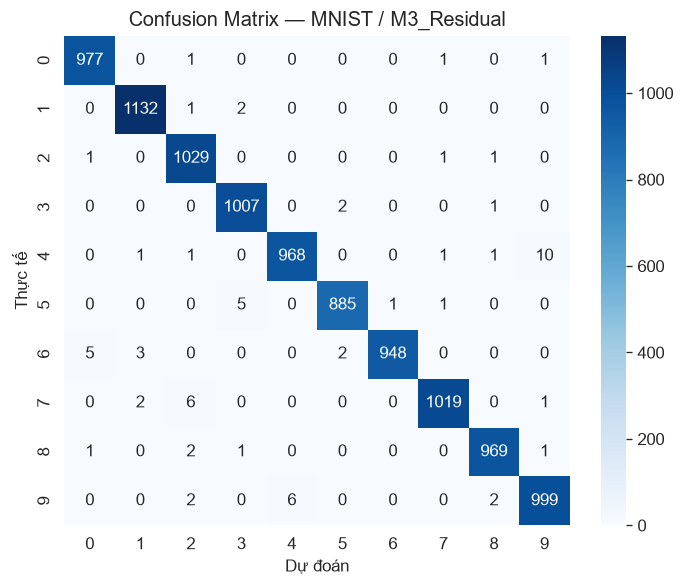

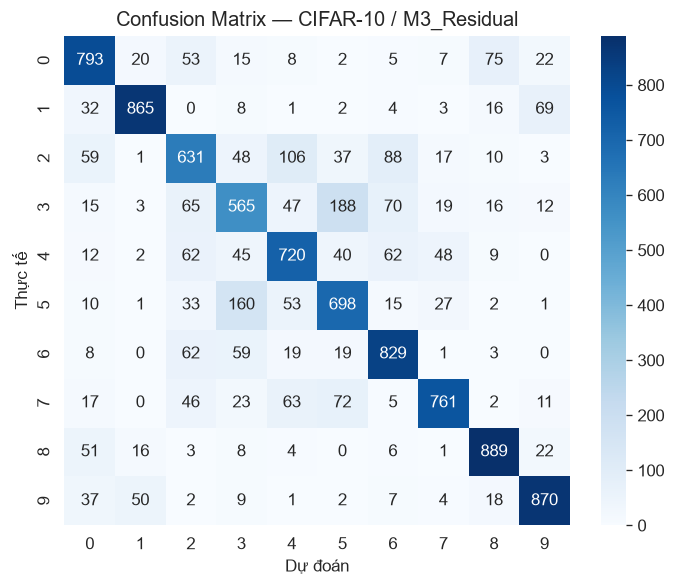

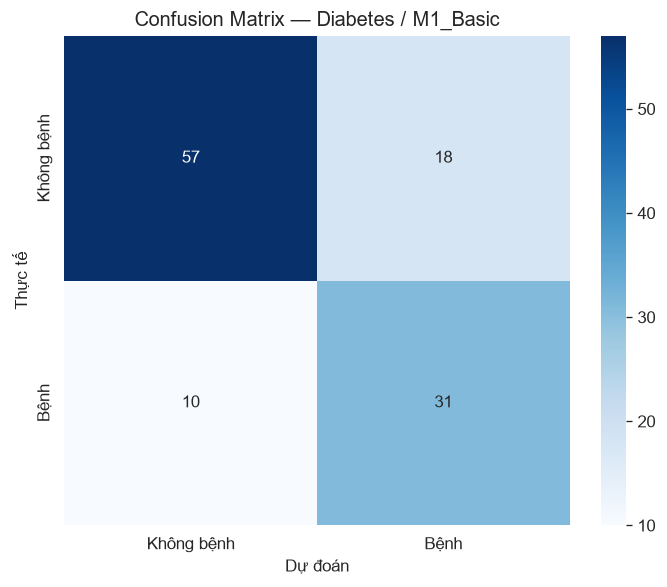

In [15]:
# Cell 8: Confusion matrix của mô hình tốt nhất mỗi dataset
for dataset in df['Dataset'].unique():
    best = df[df['Dataset'] == dataset].sort_values('F1', ascending=False).iloc[0]
    r = all_results[(dataset, best['Model'])]
    if dataset == 'Diabetes':
        labels = ['Không bệnh', 'Bệnh']
    else:
        labels = [str(i) for i in range(10)]
    plot_confusion(r['y_true'], r['y_pred'], labels,
                   f"Confusion Matrix — {dataset} / {best['Model']}",
                   save_path=f"figures/cm_{dataset}.png")